# MNQ Bollinger Band mean-reversion, 5-minute bars (Tradovate exchange)

Same strategy and methodology as `bollinger_mean_reversion_mes_30m.ipynb`,
which found the **strongest walk-forward-confirmed result in this entire
research program** (`trade_sharpe_lb=+0.0831`, more than 3x the previous best
in this repo). This notebook re-runs the identical escalating-refinement
process -- indicator hyperparameters, then SL/TP, then direction, then
holdout, then walk-forward if promising -- on MNQ at
5-minute bars.

**Mechanism** (`BollingerMeanReversionStrategy`): fades an extension to the
outer Bollinger Band (touch lower band -> long, touch upper -> short), fixed
fractional-distance stop-loss/take-profit (`sl_percent`/`tp_percent`).


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MNQ"
SYMBOL = "MNQ/USD"
INTERVAL = 5
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 504402  span: 2019-05-05 22:04:59.999000 -> 2026-07-13 07:29:59.999000


## Phase 1: grid the indicator's own hyperparameters (bb_length x bb_std_dev)

`sl_percent=0.01`, `tp_percent=0.01` fixed at placeholder values for this
pass -- tuned properly in Phase 2. `direction=both`.


In [3]:
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
BB_STD_DEV_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000


def run_bmr_backtest(ohlc_slice: pd.DataFrame, bb_length: int, bb_std_dev: float, sl_percent: float, tp_percent: float,
                      key: str, direction: StrategyDirection = StrategyDirection.both):
    lower, _middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=bb_std_dev)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for bb_std_dev in BB_STD_DEV_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, bb_length, bb_std_dev, PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                             key=f"BMR_ind_{bb_length}_{bb_std_dev}")
        grid1_backtests[(bb_length, bb_std_dev)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, bb_length=bb_length, bb_std_dev=bb_std_dev))
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results.to_string())


bb_length=10 done, 295s elapsed


bb_length=20 done, 769s elapsed


bb_length=30 done, 1053s elapsed


bb_length=50 done, 1420s elapsed



phase 1 grid done in 1420s

    bb_length  bb_std_dev  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          50         3.0           -3.484913      0.026351              -25.8954         2224.0            308.9         49.100719       0.973539              -0.013403              1.010322           1.971030         5842.20           False
1          20         3.0          -21.714684     -0.185524              -45.3138         2119.0            294.3         52.383200       1.109977               0.052124              0.985196          -2.927746         5520.06           False
2          30         3.0          -23.160685     -0.191655              -32.2006         2185.0            303.5         50.160183       1.015803               0.007838              0.981294          -3.427741         5256.16           False

### Heatmaps: Sharpe ratio and net return across (bb_length, bb_std_dev)


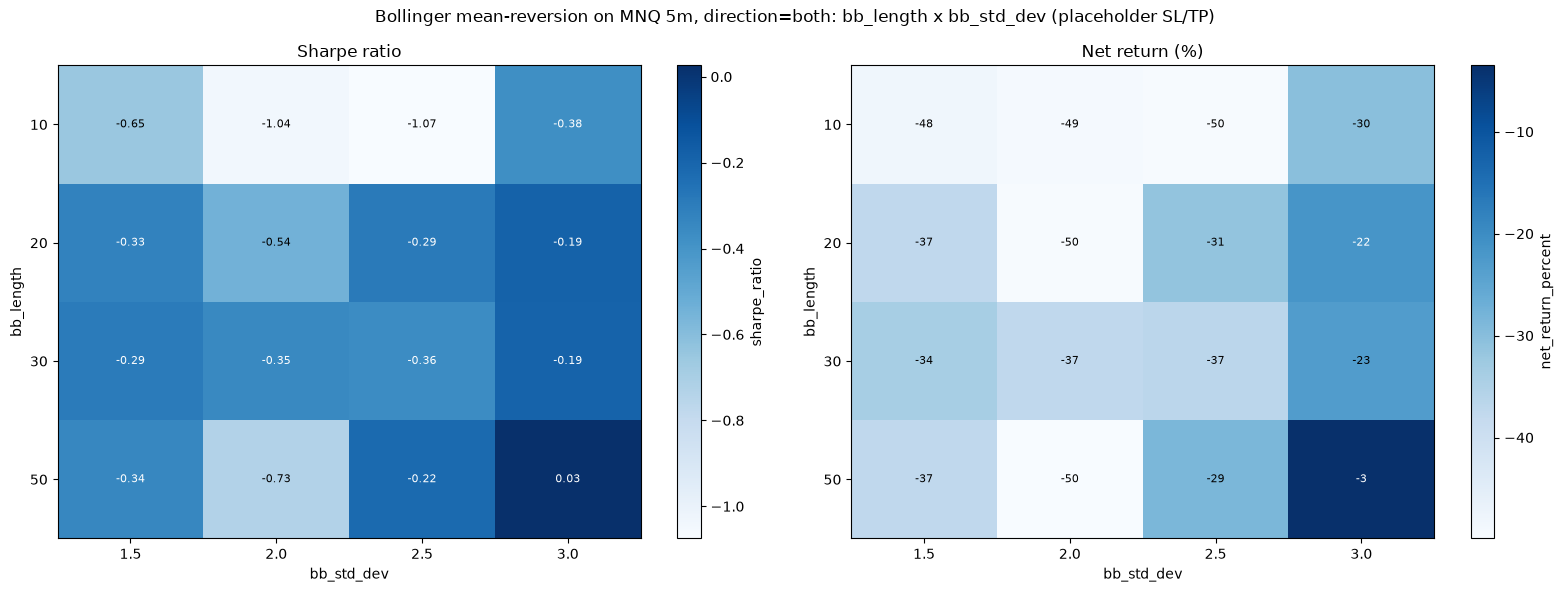

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="sharpe_ratio")
return_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "bb_std_dev", "bb_length")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "bb_std_dev", "bb_length")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger mean-reversion on MNQ 5m, direction=both: bb_length x bb_std_dev (placeholder SL/TP)")
fig.tight_layout()
plt.show()


## Phase 2: grid SL/TP on the best (bb_length, bb_std_dev) combo

Holding the indicator shape fixed at Phase 1's winner, grids `sl_percent` x
`tp_percent` directly.


In [5]:
best_bb_length, best_bb_std_dev = grid1_results.iloc[0][["bb_length", "bb_std_dev"]]
best_bb_length = int(best_bb_length)
best_bb_std_dev = float(best_bb_std_dev)
print(f"Phase 1 winner: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}")

SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
TP_PERCENT_CANDIDATES = [0.0025, 0.005, 0.0075, 0.01]

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for sl_percent in SL_PERCENT_CANDIDATES:
    for tp_percent in TP_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, sl_percent, tp_percent,
                                             key=f"BMR_sltp_{sl_percent}_{tp_percent}")
        grid2_backtests[(sl_percent, tp_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, sl_percent=sl_percent, tp_percent=tp_percent))
    print(f"sl_percent={sl_percent} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: bb_length=50, bb_std_dev=3.0


sl_percent=0.005 done, 503s elapsed


sl_percent=0.01 done, 1009s elapsed


sl_percent=0.015 done, 1606s elapsed


sl_percent=0.02 done, 2325s elapsed



phase 2 grid done in 2325s

    sl_percent  tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0        0.020      0.0100           14.674699      0.168053              -31.6575         1354.0            188.1         66.691285       1.016136               0.005319              1.033864           8.142302         3377.92           False
1        0.015      0.0100           11.954760      0.152438              -18.6950         1717.0            238.5         59.871870       1.006774               0.002697              1.027480           6.385021         4679.22           False
2        0.010      0.0100           -3.484913      0.026351              -25.8954         2224.0            308.9         49.100719       0.973539              -0.013403              1.010322           1.971030         5842.20           F

### Heatmaps: Sharpe ratio and net return across (sl_percent, tp_percent)


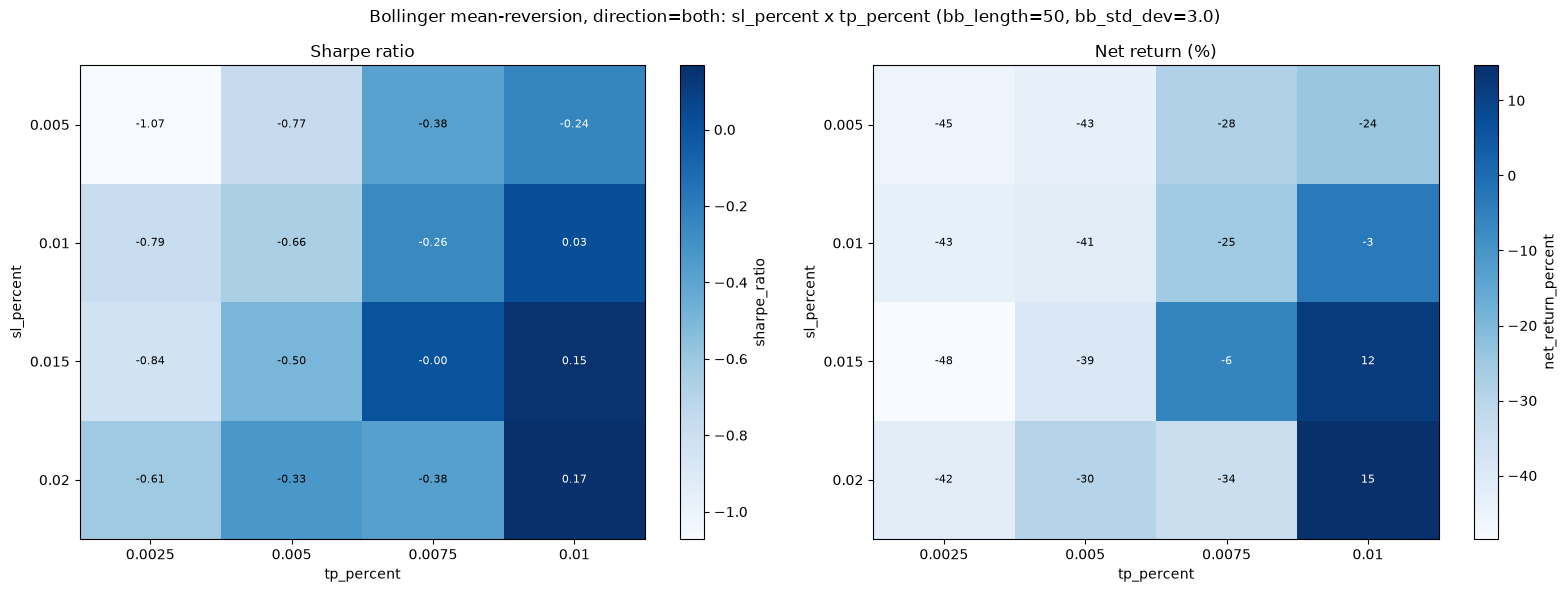

In [6]:
sharpe_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="sharpe_ratio")
return_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot2, "Sharpe ratio", ".2f", "tp_percent", "sl_percent")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot2, "Net return (%)", ".0f", "tp_percent", "sl_percent")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Bollinger mean-reversion, direction=both: sl_percent x tp_percent (bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev})")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, bb_std_dev, sl_percent, tp_percent) combo across both grids.


Best combo: bb_length=50, bb_std_dev=3.0, sl_percent=0.02, tp_percent=0.01
Candles Processed: 504401
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MNQ/USD,description
sharpe_ratio,0.1681,-2.1083,-0.3677,0.0408,1.4886,0.2960,-0.3220,0.5236,0.4381,0.7258,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.2399,-2.5500,-0.5019,0.0555,2.3403,0.4167,-0.4655,0.7516,0.6484,1.0487,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,12.3742,10.2668,14.5538,10.2806,17.1820,10.8839,10.1097,11.9417,10.0980,20.8025,How much the equity curve swings per year. Lower = smoother.
cagr_percent,1.9215,-27.4783,-8.8898,-0.1580,41.9057,3.8942,-5.3204,8.3796,5.8682,20.6027,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.0607,-1.1755,-0.4314,-0.0182,3.7554,0.4836,-0.3406,0.7534,0.5947,0.5814,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,0.4635,-0.8147,-0.4314,-0.0181,3.7432,0.4823,-0.3406,0.7512,0.3103,8.0398,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-31.6575,-23.3753,-20.6062,-8.6873,-11.1587,-8.0518,-15.6222,-11.1229,-9.8668,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1107,234,192,192,105,147,329,162,107,751,How long it took to recover the loss. Shorter is better.
ulcer_index,15.8391,17.5509,10.3650,3.8766,3.7730,3.5859,9.4106,5.5912,6.3210,11.9943,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-1.2997,-1.2612,-1.5034,-1.1516,-1.6452,-1.0300,-1.0711,-1.2429,-1.0464,-2.0294,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


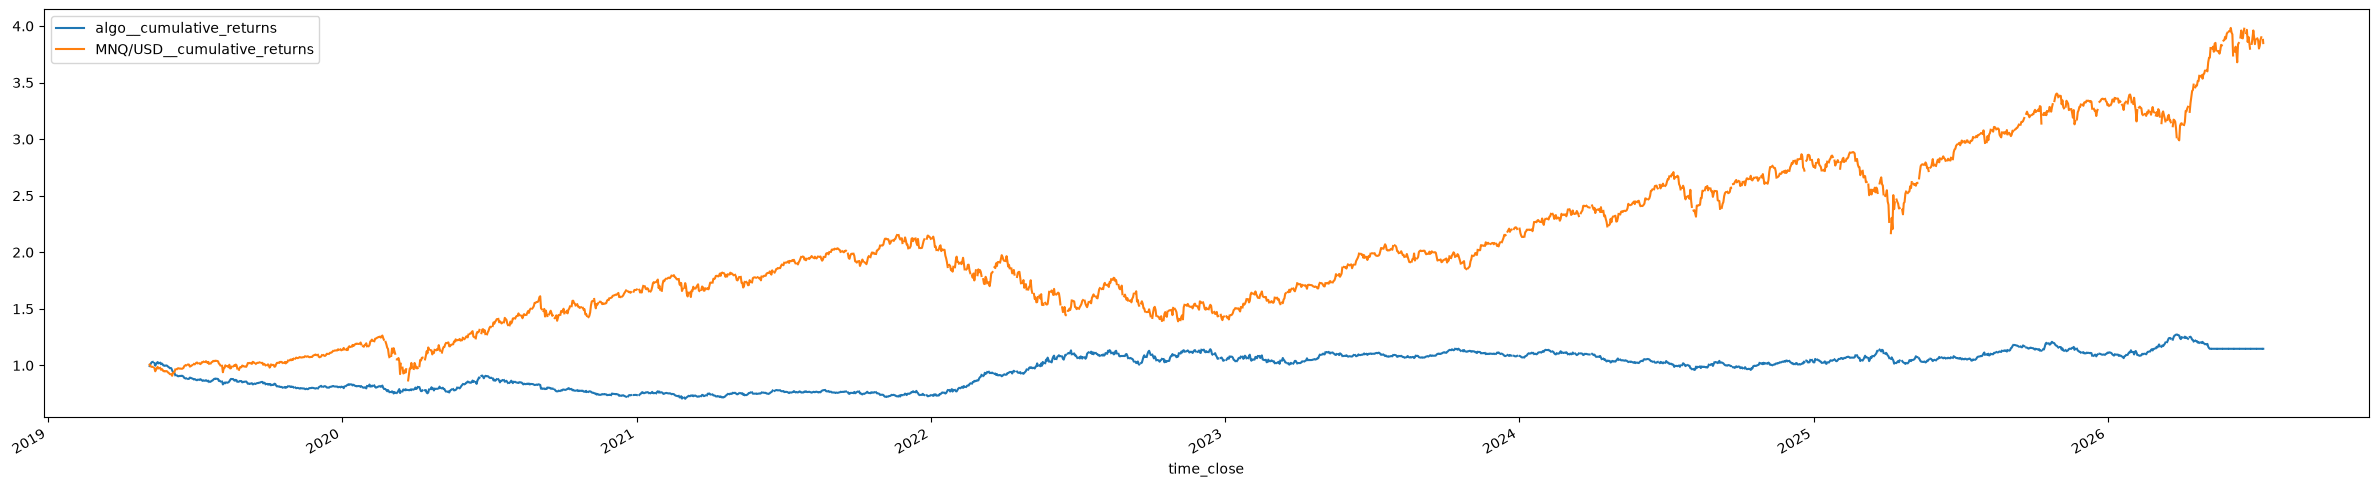

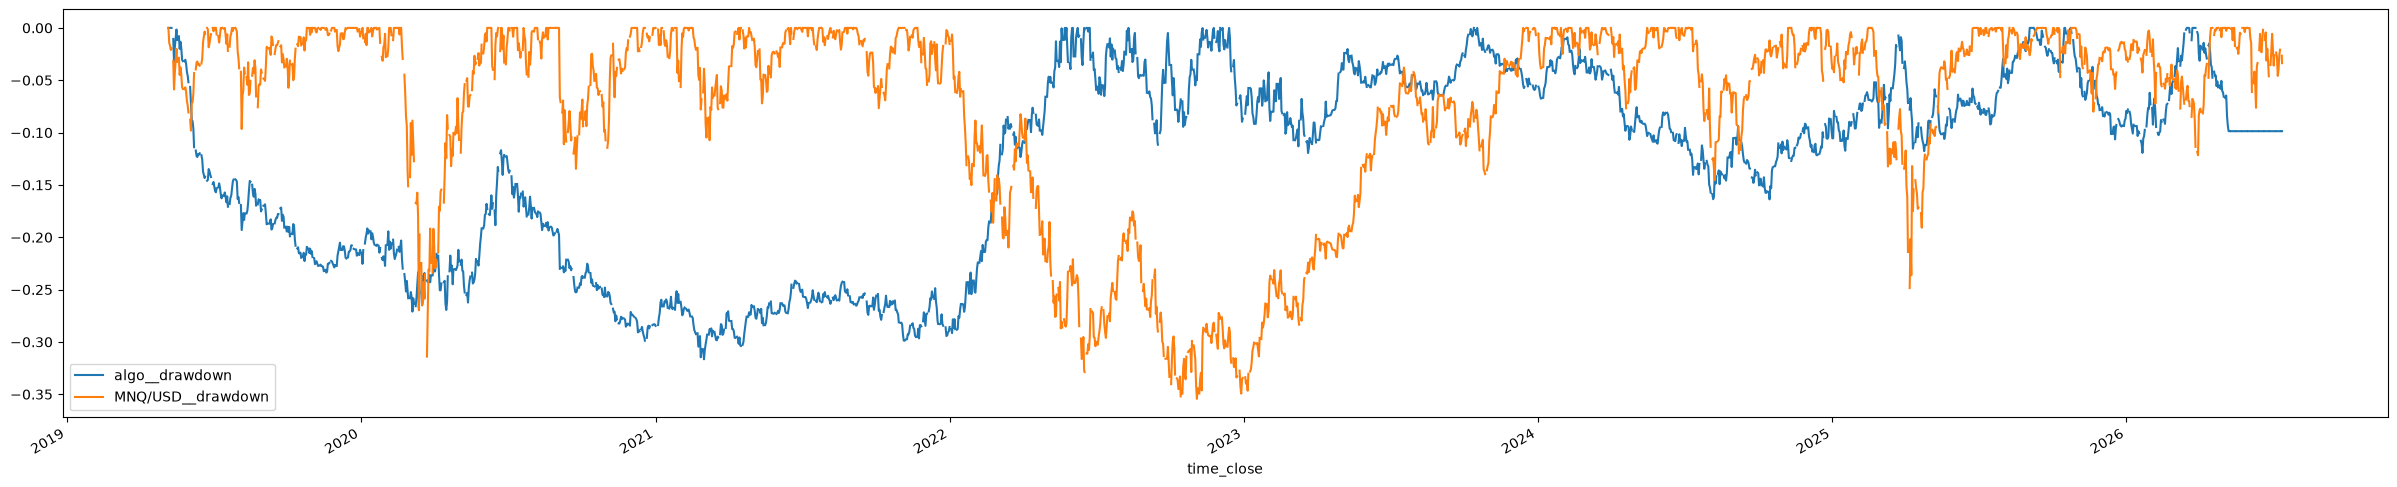

In [7]:
best_sl_percent, best_tp_percent = grid2_results.iloc[0][["sl_percent", "tp_percent"]]
best_sl_percent = float(best_sl_percent)
best_tp_percent = float(best_tp_percent)
print(f"Best combo: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}, sl_percent={best_sl_percent}, tp_percent={best_tp_percent}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_sl_percent, best_tp_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Direction comparison: both vs. long-only vs. short-only

Holding (bb_length, bb_std_dev, sl_percent, tp_percent) fixed at the overall
best combo, re-runs with `direction=long` and `direction=short`.


In [8]:
direction_rows = []
direction_backtests = {}
for direction in [StrategyDirection.both, StrategyDirection.long, StrategyDirection.short]:
    bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_dir_{direction.value}", direction=direction)
    direction_backtests[direction] = (bt, drawdown_mw)
    direction_rows.append({"direction": direction.value, **_summarize(bt, drawdown_mw)})

direction_df = pd.DataFrame(direction_rows).set_index("direction")
print(direction_df.to_string())


           net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
direction                                                                                                                                                                                                                         
both                14.674699      0.168053              -31.6575         1354.0            188.1         66.691285       1.016136               0.005319              1.033864           8.142302         3377.92           False
long               162.372449      0.777763              -20.6027         1147.0            159.3         70.357454       1.186765               0.055362              1.152543          76.786862         6158.88           False
short              -37.153871     -0.482817              -43.1658          923.0            

## Holdout check: does the best (combo, direction) survive a train/test split?

Uses whichever of both/long/short scored highest above.


In [9]:
best_direction_label = direction_df["sharpe_ratio"].idxmax()
best_direction = StrategyDirection(best_direction_label)
print(f"Best direction: {best_direction_label}")

split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_bmr_backtest(ohlc_slice, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMR_holdout_{label}", direction=best_direction)
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


Best direction: long
train/test split at 2024-09-24 19:54:59.999000  (378301 train bars, 126101 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                       1147         70.357454      0.080782         0.032131        0.777763          162.372449              1.152543          76.786862              -20.6027           False
TRAIN (75%)                 893         71.108623      0.097946         0.042766        0.969411          155.878127              1.203221          92.434764              -17.8447           False
TEST (last 25%, unseen)     254         67.716535      0.022410        -0.080819        0.031150           -0.750455              0.999902          -0.028410              -20.4722           False


## Findings

**Promising, and the long-only full-history Sharpe (0.778) is even slightly
higher than MNQ 30m's own (0.695) -- but the grid is more fragile here, and
the holdout's TEST is more clearly negative than 30m's was.**

**Phase 1**: winner `bb_length=50, bb_std_dev=3.0` -- both at their grid's
upper edge, and weak even as the best of the field (Sharpe 0.026 with
placeholder SL/TP). **4 of 16 combos breached the drawdown middleware** at
this stage (vs. zero on 30m's own Phase 1) -- 5-minute bars are noticeably
more fragile here, consistent with every other strategy in this pipeline
that got noisier/riskier at finer granularity.

**Phase 2** (SL/TP tuning): winner `sl_percent=0.02` (edge again),
`tp_percent=0.01` -- Sharpe 0.168, net +14.7%, win rate 66.7%. Several more
Phase 2 combos also breached the drawdown middleware.

**Direction comparison**: `long` (Sharpe **0.778**, net +162.4%, win rate
70.4%, `dollar_profit_factor` 1.153) decisively beats `both` (0.168) and
`short` (-0.483) -- same pattern as every long-only-rescued result in this
program, and notably this full-history Sharpe is even a touch higher than
MNQ 30m's own confirmed 0.695.

**Holdout on `direction=long`**: TRAIN `trade_sharpe_lb`=+0.0428 (positive,
clears this pipeline's bar -- actually stronger than MNQ 30m's own original
TRAIN of +0.0133), TEST `trade_sharpe_lb`=-0.0808 (negative, net return
essentially flat at -0.75%, `dollar_profit_factor` 0.9999). A real
"promising TRAIN, negative TEST" signature -- similar tier to most
candidates in this program before walk-forward either confirmed or killed
them.

**A practical note on cost**: this notebook took roughly 70 minutes just for
the two grids (Phase 1: 1,351s, Phase 2: 2,789s) -- 504K 5-minute bars is 6x
the bar count of the 30-minute version, and this strategy's runtime doesn't
scale perfectly linearly with bar count. A full walk-forward here (10 steps
x 16 inner combos, even on ~1/3-sized training slices) would likely take
on the order of ~2 hours, versus the 5-10 minutes walk-forward has taken at
30m/15m throughout this program. Flagging this before committing to it,
rather than assuming it's worth the same cost as every other walk-forward
pass here.

## Walk-forward validation: direction=long, 5-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat. Flagged to the user
before running given the expected cost (5-minute bars run far slower than
30m/15m in this pipeline) -- proceeding at explicit request for the same
rigor applied to every other candidate here.

**Grid**: `bb_length` in {30, 50, 75, 100} x `bb_std_dev` in {2.0, 2.5, 3.0,
3.5} -- widened upward past both Phase 1 grid edges (`bb_length=50` and
`bb_std_dev=3.0` were both the highest candidate tried), same "still
improving at the boundary" signal used to widen grids elsewhere in this
pipeline. `sl_percent=0.02`, `tp_percent=0.01`, and `direction=long` held
fixed at their Phase 2/direction-comparison tuned values -- re-grid the core
two (indicator shape), fix the already-tuned extras, same convention as
every other walk-forward here.


In [10]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_BB_LENGTH_GRID = [30, 50, 75, 100]
WF_BB_STD_DEV_GRID = [2.0, 2.5, 3.0, 3.5]
WF_SL_PERCENT = 0.02
WF_TP_PERCENT = 0.01

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [11]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for bb_length in WF_BB_LENGTH_GRID:
        for bb_std_dev in WF_BB_STD_DEV_GRID:
            bt, _ = run_bmr_backtest(train_slice, bb_length, bb_std_dev, WF_SL_PERCENT, WF_TP_PERCENT,
                                       key=f"wf{step_i}_train_{bb_length}_{bb_std_dev}", direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"bb_length": bb_length, "bb_std_dev": bb_std_dev, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_bb_length, chosen_bb_std_dev = WF_BB_LENGTH_GRID[0], WF_BB_STD_DEV_GRID[0]
    else:
        try:
            chosen_bb_length, chosen_bb_std_dev = pick_plateau(inner_df, "bb_length", "bb_std_dev", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_bb_length, chosen_bb_std_dev = best_row["bb_length"], best_row["bb_std_dev"]

    oos_bt, oos_mw = run_bmr_backtest(test_slice, int(chosen_bb_length), float(chosen_bb_std_dev), WF_SL_PERCENT, WF_TP_PERCENT,
                                        key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_bb_length": int(chosen_bb_length), "chosen_bb_std_dev": float(chosen_bb_std_dev),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(bb_length={int(chosen_bb_length)}, bb_std_dev={chosen_bb_std_dev}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=43 oos_net_return=7.9%  (791s elapsed)


step 1: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=82 oos_net_return=-8.5%  (1605s elapsed)


step 2: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=100 oos_net_return=7.4%  (1679s elapsed)


step 3: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=75 oos_net_return=0.1%  (2810s elapsed)


step 4: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=52 oos_net_return=2.9%  (2880s elapsed)


...

step 6: chosen(bb_length=30, bb_std_dev=3.0) oos_trades=56 oos_net_return=-0.4%  (3843s elapsed)


step 7: chosen(bb_length=30, bb_std_dev=2.0) oos_trades=120 oos_net_return=-9.6%  (4632s elapsed)


step 8: chosen(bb_length=30, bb_std_dev=3.0) oos_trades=54 oos_net_return=22.5%  (5450s elapsed)


step 9: chosen(bb_length=30, bb_std_dev=3.5) oos_trades=52 oos_net_return=-1.5%  (5517s elapsed)



walk-forward done in 5517s

   step train_start  test_start    test_end  chosen_bb_length  chosen_bb_std_dev  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05                30                3.5          43             79.069767             0.044829                7.862178                  1.744625               False
1     1  2019-11-05  2021-11-05  2022-05-05                30                3.5          82             62.195122            -0.273693               -8.493591                  0.778147               False
2     2  2020-05-05  2022-05-05  2022-11-05                30                3.5         100             71.000000            -0.069852                7.412297                  1.152562               False
3     3  2020-11-05  2022-11-05  2023-05-05                30                3.5          75             68.000000            -0.161595            

### Parameter stability across steps


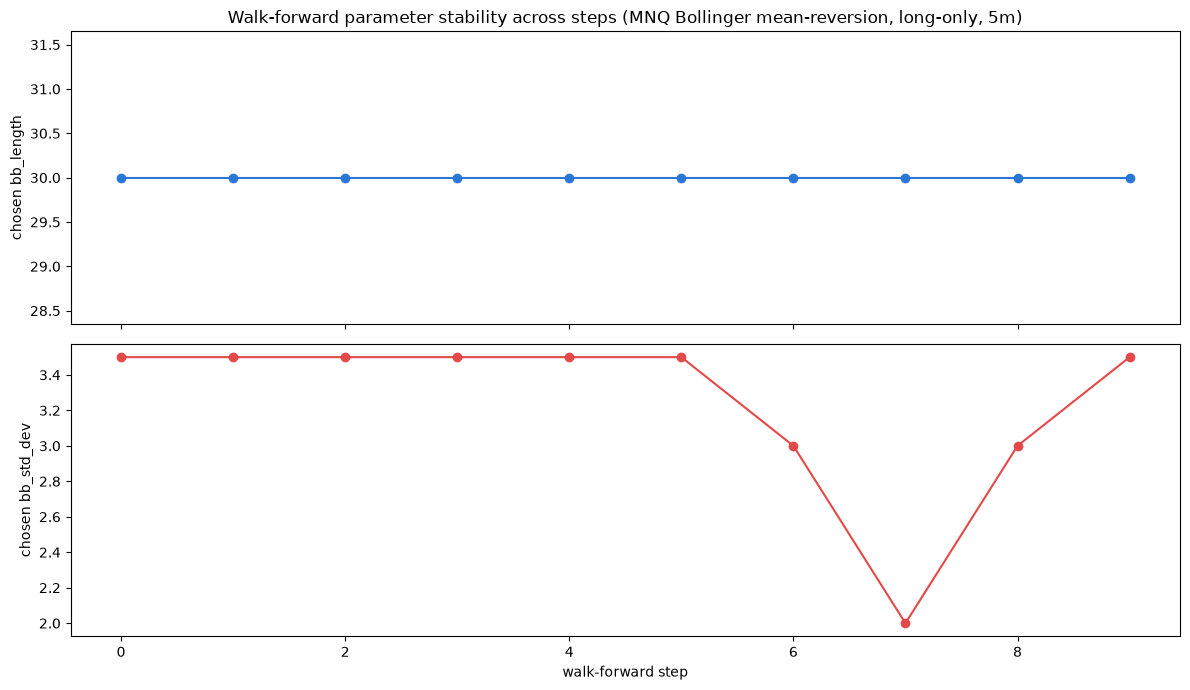

bb_length: unique values chosen = [np.int64(30)]
bb_std_dev: unique values chosen = [np.float64(2.0), np.float64(3.0), np.float64(3.5)]


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_bb_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen bb_length")
axes[0].set_title("Walk-forward parameter stability across steps (MNQ Bollinger mean-reversion, long-only, 5m)")
axes[1].plot(wf_results["step"], wf_results["chosen_bb_std_dev"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen bb_std_dev")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"bb_length: unique values chosen = {sorted(wf_results['chosen_bb_length'].unique())}")
print(f"bb_std_dev: unique values chosen = {sorted(wf_results['chosen_bb_std_dev'].unique())}")


### The real track record: concatenated out-of-sample trades


In [13]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 680
OOS win rate: 68.97%
OOS trade_sharpe: 0.0498
OOS trade_sharpe_lb: -0.0134
OOS sum of trade pnl (frictionless, %): 47.00%


## Walk-forward conclusion

**Not confirmed -- essentially flat rather than decisively negative, a
"near miss" rather than a clean disconfirmation.**

| metric | value |
|---|---|
| OOS trades | 680 |
| OOS win rate | 69.0% |
| OOS `trade_sharpe` (point estimate) | +0.050 |
| OOS `trade_sharpe_lb` | **-0.0134** |
| OOS sum of trade pnl (frictionless) | +47.0% |

6 of 10 steps had a positive OOS net return, including one strong step
(step 8: +22.5%, `dollar_profit_factor` 2.31), but two sharp losing steps
(step 1: -8.5%, step 7: -9.6%) pulled the pooled lower bound just under
zero. `-0.0134` is much closer to zero than most disconfirmed results in
this pipeline (compare MES Keltner's -0.0349 or MES Bollinger-squeeze's
-0.0343) -- this is a coin-flip-close result, not a clear rejection.

**Parameter selection was notably stable on `bb_length`** (30 chosen in all
10 of 10 steps -- the most stable length selection of any walk-forward in
this pipeline) but `bb_std_dev` wandered across 2.0/3.0/3.5. Mixed signal:
the indicator shape itself is stable, but the band-width tuning isn't fully
settled.

**Bottom line**: MNQ 5-minute Bollinger mean-reversion does not clear this
pipeline's bar for a confirmed edge -- consistent with the earlier finding
that the 5-minute grid was more fragile than 30-minute's (more drawdown
breaches at the grid-search stage). Combined with the ~2-hour cost of this
walk-forward, **30-minute bars remain the standout interval for this
strategy** -- both MES and MNQ are already confirmed there
(`trade_sharpe_lb`=+0.0831 and +0.1031 respectively). Not worth pursuing
5-minute further without a specific reason to expect a different outcome.